<a href="https://colab.research.google.com/github/dctorti-lab/Torti_PHYS471_Lab_4/blob/main/radioactivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Our first experiment was to determine the threshold voltage using Cobalt 60 as our isotope. Here is a plot of the data from the Geiger-Muller counter.

In [42]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import csv

In [43]:
filepath = "/content/drive/MyDrive/Lab_4/co60_plateau_sheets.csv"
data = np.genfromtxt(filepath, delimiter=',', names = ["C1","C2"])

In [44]:
voltage = data['C1']
counts = data['C2']

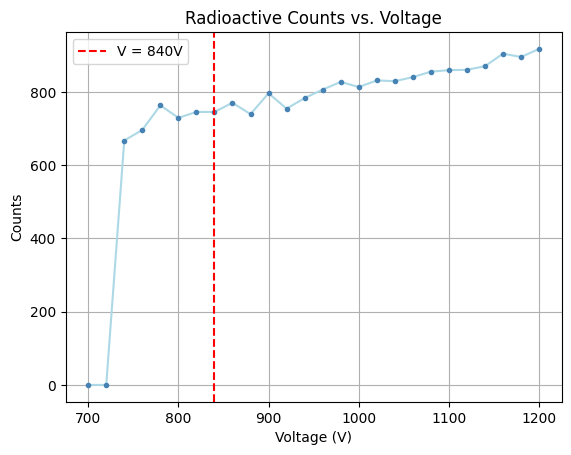

In [45]:
fig, ax = plt.subplots()
ax.plot(voltage, counts, color="lightblue", marker='o', mec='steelblue',mfc='steelblue',ms='3')
ax.axvline(x=840, color='red', linestyle='--', label='V = 840V')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Counts')
ax.set_title('Radioactive Counts vs. Voltage')
ax.grid()
ax.legend()
plt.show()

Now let's analyze our background counting and Cobalt 60 counting data using Poisson statistics. As shown in the lab report, our parameter $ \hat{\lambda}$ can be written as just the average of the count data points.

In [46]:
filepath_1 = "/content/drive/MyDrive/Lab_4/background_counting_poisson.csv"
data_1 = np.genfromtxt(filepath_1, delimiter=',', names = ["D1","D2"])
run_1 = data_1['D1']
counts_1 = data_1['D2']

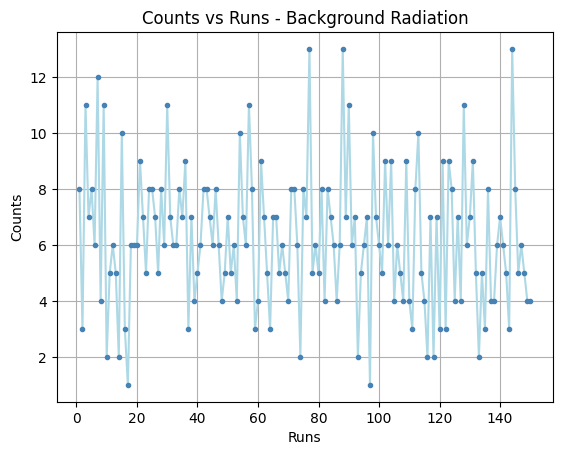

In [47]:
fig, ax = plt.subplots()
ax.plot(run_1, counts_1, color="lightblue", marker='o', mec='steelblue',mfc='steelblue',ms='3')
ax.set_xlabel('Runs')
ax.set_ylabel('Counts')
ax.set_title('Counts vs Runs - Background Radiation')
ax.grid()
plt.show()

Now we shall plot our probability histogram for the background radiation counting, and compare it to our Poisson data given our estimator.

6.24
2.4676034257284263


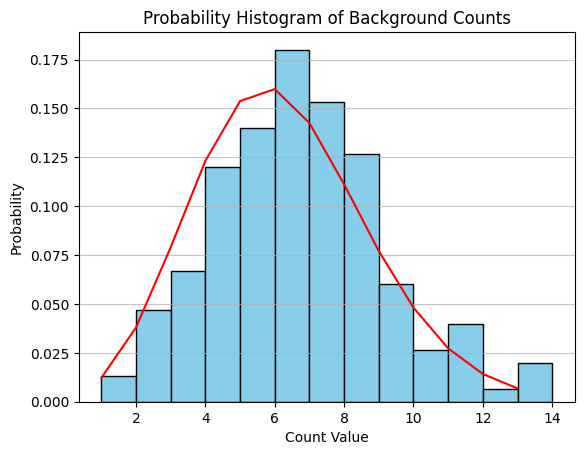

In [48]:
lambda_hat_1 = np.mean(counts_1)
print(lambda_hat_1)
print(np.std(counts_1))

counts_1 = counts_1.astype(int)
x = range(min(counts_1), max(counts_1) + 1)
y = sp.stats.poisson.pmf(x, lambda_hat_1)

plt.hist(counts_1, bins = range(min(counts_1), max(counts_1) + 2), density = True, color = 'skyblue', edgecolor = 'black')
plt.plot(x, y, color = 'red')
plt.xlabel('Count Value')
plt.ylabel('Probability')
plt.title('Probability Histogram of Background Counts')
plt.grid(axis='y', alpha=0.75)
plt.show()

Now let's do the same for Cobalt 60.

24.350666666666665
4.875622991532011


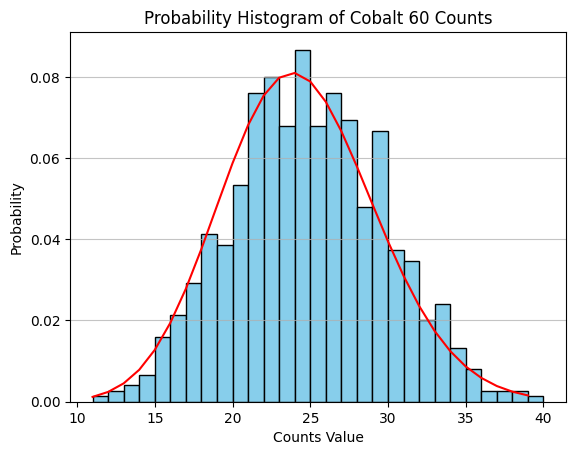

In [50]:
filepath_2 = "/content/drive/MyDrive/Lab_4/co60_counting_poisson.csv"
data_2 = np.genfromtxt(filepath_2, delimiter=',', names = ["E1","E2"])
counts_2 = data_2['E2']

lambda_hat_2 = np.mean(counts_2)
print(lambda_hat_2) # lambda_hat_2 = 24.35
print(np.std(counts_2))

counts_2 = counts_2.astype(int)
x = range(min(counts_2), max(counts_2) + 1)
y = sp.stats.poisson.pmf(x, lambda_hat_2)

plt.hist(counts_2, bins = range(min(counts_2), max(counts_2) + 2), density = True, color = 'skyblue', edgecolor = 'black')
plt.plot(x, y, color = 'red')
plt.xlabel('Counts Value')
plt.ylabel('Probability')
plt.title('Probability Histogram of Cobalt 60 Counts')
plt.grid(axis='y', alpha=0.75)
plt.show()

Now let's finally plot our half life data for Barium 137 from Cesium 137.

In [51]:
filepath_3 = "/content/drive/MyDrive/Lab_4/ba_137_halflife.csv"
data_3 = np.genfromtxt(filepath_3, delimiter=',', names = ["F1","F2"])
runs_3 = data_3['F1']
counts_3 = data_3['F2']

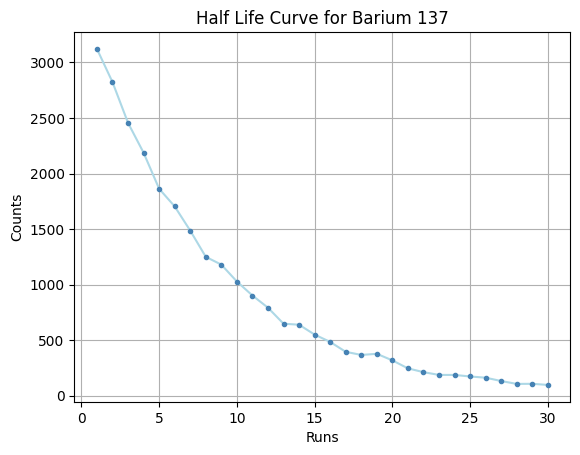

In [53]:
fig, ax = plt.subplots()
ax.plot(runs_3, counts_3, color="lightblue", marker='o', mec='steelblue',mfc='steelblue',ms='3')
ax.set_xlabel('Runs')
ax.set_ylabel('Counts')
ax.set_title('Half Life Curve for Barium 137')
ax.grid()
plt.show()